# **ESERCIZIO 9.1**

**OBIETTIVI**

L'obiettivo di questa esercitazione è risolvere il problema del commesso viaggiatore usando un algoritmo genetico. In particolare, bisogna trovare il percorso più breve che permetta al commesso viaggiatore di visitare 34 città, ciascuna solo una volta, ritornando alla città da cui è partito.

In particolare, l'esercizio deve essere svolto per due diverse configurazioni:
- 34 città posizionate casualmente su una circonferenza
- 34 città posizionate casualmente all'interno di un quadrato

Userò una rappresentazione monodimensionale, in cui ogni città è rappresentata da un numero intero (partendo da 0) e ogni percorso è quindi una sequenza di numeri interi. Per ridurre la degenerazione, impongo che il percorso parta sempre dalla stessa città, che ho scelto pari a 0.

In particolare, la funzione costo in questo esercizio è
$$
L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|
$$

**ALGORITMO GENETICO**

Un algoritmo genetico è una tecnica di ottimizzazione che trae ispirazione dalla genetica e dal meccanismo di selezione naturale. Infatti, l'evoluzione può essere vista come un percorso per trovare la soluzione ottimale, ovvero gli organismi più adatti in un ambiente (ovvero la funzione costo) che cambia. Nell'algoritmo genetico, le soluzioni del problema sono gli individui di una popolazione: essi si riproducono e sono inoltre soggetti a mutazioni casuali, che possono renderli più o meno adatti all'ambiente.

Gli algoritmi genetici si differenziano dagli altri algoritmi in quanto non lavorano direttamente con i parametri stessi, ma utilizzano una codifica dei parametri: ad esempio, un cromosoma (che rappresenta una possibile soluzione) può essere visto come una stringa di 0 e 1; i geni possono invece assumere diversi valori detti alleli (0 o 1, nel caso in cui i cromosomi siano sequenze di 0 1). Infine, la popolazione non è altro che l'insieme di tutti i cromosomi presenti nell'ambiente in una determinata generazione, mentre il fitness è il parametro che permette di misurare la bontà di una soluzione, in base alla capacità della soluzione di minimizzare la funzione costo.

Per simulare l'evoluzione della popolazione, sono necessari degli operatori di diverso tipo:
- OPERATORE DI SELEZIONE: ha il compito di selezionare i due genitori, ovvero di scegliere i due individui per la riproduzione. In particolare, è conveniente usare un algoritmo che favorisca la selezione di individui con fitness più alta come genitori.
- OPERATORE DI CROSSOVER: permette lo scambio del patrimonio genetico dei due genitori, per produrre due figli. Tipicamente viene applicato con una probabilità >50% per favorire la combinazione e la diffusione dei tratti genetici migliori.
- OPERATORI DI MUTAZIONE: introducono delle modifiche casuali al patrimonio genetico dei figli, per poter garantire la variabilità genetica. Infatti, se non ci fossero mutazioni, la popolazione rischierebbe di convergere rapidamente verso minimi locali senza poter esplorare altre possibili soluzioni migliori. Le mutazioni sono applicate tipicamente con probabilità <10%.

Infine si esegue un ciclo evolutivo su più generazioni, in cui si eseguono iterativamente i seguenti passaggi:
- INIZIALIZZAZIONE: viene creata una popolazione iniziale casuale di M individui
- VALUTAZIONE: viene calcolata la fitness di ogni individuo
- RIPRODUZIONE: vengono selezionati i due genitori, vengono applicati crossover e mutazioni per creare una nuova generazione di figli
- SOSTITUZIONE: la vecchia generazione viene rimpiazzata da quella nuova. Si può scegliere di applicare l'elitismo, ovvero il miglior individuo della generazione attuale viene copiato direttamente nella generazione successiva per non perderlo.

**IMPLEMENTAZIONE**

Ho scelto di lavorare a classi. In particolare, ho bisogno di creare le seguenti classi (che ho inserito in dei file .cpp per l'implementazione e .h per le dichiarazioni):
- città (allele)
- percorso (cromosoma)
- popolazione
- algoritmo genetico

**CITTA'**

Contiene costruttore e funzioni per ottenere posizione della città (ovvero coordinate x e y). Questa classe è importante perchè grazie alle coordinate posso calcolare le distanze tra le varie città, e quindi ordinare la popolazione partendo dall'individuo migliore (ovvero quello che minimizza la norma L1). Nella mia implementazione, una città è rappresentata da un numero intero da 0 a 33.

**PERCORSO**

La classe Percorso rappresenta una possibile soluzione del problema del commesso viaggiatore, ovvero continene una possibile sequenza per visitare tutte e 34 le città. Nella mia implementazione, un percorso è pertanto un vector di interi.

In questa classe ho implementato le funzioni per restituire il percorso e per calcolare e per restituire la lunghezza del percorso (servono quando devo ordinare i percorsi di una popolazione in base al loro fitness).

Ho inoltre implementato la funzione controlla_vincoli per controllare che effettivamente la prima città sia in testa alla sequenza, che non ci siano città ripetute più volte, e che siano tutte presenti.

*OPERATOR<*

Dato che dovrò confrontare percorsi diversi tra loro per una data popolazione, ho bisogno di definire un criterio di ordinamento tra due percorsi. In particolare, un percorso è minore di un altro se la sua lunghezza $m_\text{L1}$ è minore di quella dell'altro percorso.

**POPOLAZIONE**

La classe popolazione conterrà l'insieme di più individui, ovvero l'insieme di più percorsi. In particolare, nella mia implementazione un elemento della classe popolazione è un vector di tipo Percorso: quindi, una popolazione contiene più percorsi.

In questa classe ho bisogno di due diverse funzioni per impostare la popolazione: la funzione Genera_popolazione (per generare "da zero" la popolazione iniziale), e la funzione SetPopolazione, per sostituire ad ogni step del ciclo evolutivo la popolazione della generazione precedente con quella della nuova generazione.

*GENERA POPOLAZIONE*

Ho implementato il metodo per generare una popolazione di individui in questo modo:
- eseguo un ciclo for sul numero di individui, in modo da creare ad ogni step un nuovo percorso. All'inizio di questo ciclo for creo un vector di interi, $percorso$, che rappresenta l'individuo da generare.
- creo un ciclo for sul numero delle città e "inizializzo" l'individuo inserendo le città in ordine (città 0 in posizione 0 e via dicendo). Mescolerò gli elementi in seguito.
- creo un ciclo for di 100 passi, in cui estraggo casualmente due indici $a$ e $b$ del vector e vado a scambiare gli elementi in quelle posizioni. In particolare, per preservare l'inizio di ogni percorso, ho scelto di estrarre casualmente il numero a partire da 1 e non da 0: in questo modo mi assicuro che la città 0 sia sempre la prima città di ogni percorso. In particolare, ho scelto di fare 100 scambi per generare soluzioni sufficientemente diverse.
- inserisco il percorso creato come un elemento della classe Percorso e controllo che effettivamente soddisfi i vincoli imposti
- se soddisfa i vincoli, aggiungo il percorso alla popolazione

Inoltre, in questa classe implemento una funzione che ordini la popolazione dal percorso migliore (più breve) a quello peggiore (più lungo):

*ORDINA*

Ho implementato questo metodo per calcolare la lunghezza di tutti i percorsi e per ordinarli in ordine di lunghezza L1 crescente. Calcolo la lunghezza per ogni percorso della popolazione; uso l'algoritmo sort della libreria algorithm per ordinare l'array di Percorsi.


**ALGORITMO GENETICO**

In questa classe devo implementare i diversi operatori dell'algoritmo genetico: mutazioni, crossover, selezione. In particolare, nel costruttore assegno le probabilità di crossover (80%), di scambio (10%), di shift (10%), di permutazione (10%), di inversione (10%) e di elitismo (80%).

*SELEZIONE*

Ho deciso di implementare l'algoritmo di selezione basato sul rango: ovvero scelgo l'individuo scelto per la riproduzione basandomi sulla sua posizione all'interno della popolazione, precedentemente ordinata dal migliore al peggiore. Questa funzione mi restituisce l'indice dell'individuo scelto come genitore.

L'indice dell'individuo scelto è ottenuto dalla formula $j= int(M \times r^p)+1$ (nel codice non ho aggiunto +1 perchè gli indici del vettore partono da 0) dove $r$ è un numero casuale uniformemente distribuito in $r\in[0,1)$ e M sono gli individui della popolazione.

In particolare, p è il parametro che entra direttamente in gioco nella selezione: aumentare il valore di p significa avere una preferenza verso gli individui associati a un indice j più basso (ovvero, dato che la popolazione è ordinata, i percorsi più brevi), dal momento che $r$ può valere al più 1. Ho scelto p=2.


*CROSSOVER*

Una volta selezionati i due genitori, eseguo il crossover. In particolare, ho implementato il crossover nel seguente modo:
- TAGLIO: scelgo casualmente la posizione di taglio, ovvero scelgo l'indice (ovvero la città) in corrispondenza del quale andrò ad eseguire il taglio
- CONSERVAZIONE: mantengo inalterata la parte precedente al taglio: il figlio 1 avrà la stessa sequenza iniziale del primo genitore; il figlio 2 avrà la stessa sequenza iniziale del secondo genitore
- COMPLETAMENTO: completo la sequenza dopo il taglio, inserendo i numeri (ovvero le città) mancanti in ciasun figlio nell'ordine in cui compaiono nell'altro genitore.

Concretamente, per riempire ciascun figlio (1,2) con le città mancanti ho eseguito un ciclo esterno sugli indici k del genitore (2,1) e per ogni k ho controllato se la città corrispondente fosse presente o meno nel figlio. Se la città manca, la aggiungo nel figlio. In questo modo, dal momento che k viene incrementato progressivamente, aggiungo le città mancanti nell'ordine in cui compaiono nel genitore.

Ho scelto per il crossover una probabilità del 80%: è bene infatti usare una probabilità superiore al 50% in quanto se la probabilità fosse più bassa, i figli sarebbero troppo frequentemente delle copie identiche dei genitori. Inoltre, una probabilità troppo alta sarebbe controproducente in quanto si perderebbero le informazioni sui percorsi buoni.

Dopo aver generato i figli, eseguo un controllo per verificare che effettivamente i vincoli siano ancora rispettati.

*MUTAZIONE 1: SCAMBIO DI UNA COPPIA*

In questo metodo implemento la mutazione di scambio di coppia, che consiste nello scambiare le posizioni di due città scelte a caso nel percorso. In particolare, ho implementato questa funzione estraendo casualmente l'indice di una delle due città tra 1 e N-1 (così la città iniziale non viene toccata); infine, continuo ad estrarre l'indice dell'altra città fino a quando il valore estratto risulta diverso da quello estratto in precedenza per la prima città. Controllo sempre che il percorso ottenuto rispetti i vincoli.

*MUTAZIONE 2: SHIFT DI M CITTA' CONTIGUE*

In questo metodo implemento lo shift di un blocco di città di un certo numero di posizioni in avanti. Per prima cosa, estraggo casualmente il numero di M città da spostare (ovvero da 1 a N-2 città massimo) ed estraggo il punto di partenza $i$ del blocco, partendo dall'indice 1 (anzichè da 0) per non modificare la posizione della città iniziale. Dopodichè, ricostruisco il blocco che conterrà le città da spostare riempiendo un vettore di interi con le M città estratte a partire dalla i-esima posizione del percorso iniziale. Rimuovo dal percorso il blocco di città da shiftare, tenendo nel percorso solamente le altre città. Estraggo casualmente la posizione $j$ in cui andrò ad inserire il blocco, evitando l'indice 0 per non toccare la città iniziale del percorso. Infine, costruisco il nuovo percorso finale: inserisco fino alla posizione $j$ le città non incluse nel blocco da shiftare, inserisco il blocco da shiftare a partire dalla posizione $j$ estratta e inserisco le città mancanti. Controllo che il percorso ottenuto rispetti i vincoli.

*MUTAZIONE 3: PERMUTAZIONE TRA GRUPPI*

Scambio due blocchi diversi di M<N/2 città, cercando di lasciare inalterati i pezzi di percorso già ottimizzati. Questa mutazione permette di quindi di preservare un pezzo di percorso già ottenuto. Per prima cosa, estraggo casualmente la dimensione M<N/2 del blocco di città da permutare, estraendo casualmente un numero tra 1 e N/2-1. Scelgo gli indici di partenza dei due blocchi, in modo che non siano sovrapposti e in modo che la città iniziale resti sempre in posizione 0: in particolare, scelgo l'indice del primo blocco estraendolo tra 1 e N/2-M, in modo che sia nella prima metà del percorso; scelgo l'indice del secondo blocco estraendolo casualmente tra N/2 e N-M-1, in modo che venga scelto nella metà "libera" del percorso, così da non sovrapporsi col primo blocco. Dopodichè, scambio uno ad uno gli elementi dei due blocchi, utilizzando la funzione swap. Controllo che il nuovo percorso rispetti i vincoli.

*MUTAZIONE 4: INVERSIONE DELL'ORDINE*

Seleziono M città contigue del percorso e ne ribalto l'ordine, riordinandole dall'ultima alla prima. Questa mutazione è utile per sbrogliare eventuali incroci. Per prima cosa, estraggo casualmente la dimensione M del blocco di città da invertire, imponendo che sia formato da almeno 2 città e al massimo N-1 città (così la prima città non viene toccata). Dopodichè estraggo casualmente la posizione di partenza del blocco, partendo da 1 per non modificare la città iniziale. Infine, inverto il blocco scambiando progressivamente gli elementi esterni andando verso il centro. Controllo che il percorso così ottenuto soddisfi i vincoli.

*EVOLUZIONE*

Questo metodo è il cuore della simuazione in quanto implementa un ciclo evolutivo di m_gen generazioni:
1. Genero la popolazione iniziale, formata da m_individui percorsi, ciasuno formato da citta.size() città
2. Controllo che tutti i percorsi soddisfino i vincoli richiesti
3. Per ogni generazione: ordino la popolazione in base alla lunghezza L1 degli individui e creo un vettore di Percorso che conterrà la nuova popolazione, ovvero la popolazione dei figli
4. Permetto direttamente il passaggio del miglior individuo (posizionato in 0 dato che la popolazione è ordinata) alla generazione successiva, con una probabilità dell'80%. Ho scelto di clonare il migliore con una probabilità alta, ma diversa da 1 in quanto altrimenti ci sarebbe stato il rischio di avere una convergenza troppo rapida, verso un minimo locale e non verso il minimo globale.
5. Genero i figli finchè la popolazione è piena:
   - Seleziono padre e madre tramite selezione per rango
   - Genero due Percorsi "figlio1" e "figlio2" che conterranno i figli
   - Eseguo il crossover con probabilità dell'80%; se il crossover non avviene, i due figli saranno copie identiche rispettivamente di padre e madre
   - Applico eventuali mutazioni (con probabilità 10%) ad entrambi i figli
   - Controllo i vincoli: se sono rispettati, aggiungo il figlio alla popolazione. Prima di farlo, mi assicuro anche che la popolazione non sia già "completa" (dal momento che all'inizio potrebbe essersi aggiunto anche l'individuo migliore), imponendo che la nuova popolazione abbia dimensione <= al numero di individui
7. Sostituisco la popolazione precedente con la nuova popolazione

Inoltre, in questo metodo ho implementato anche il calcolo della media della metà migliore della popolazione, ovvero degli individui posizionati dall'indice 0 all'indice N/2-1. In particolare, questo metodo prende in ingresso la reference al fileout di stampa per poter stampare i valori ottenuti su file. Dunque, ad ogni generazione, prendo la metà migliore e faccio la media delle lunghezze L1 degli individui selezionati, e salvo nel fileout il numero associato alla generazione, la lunghezza L1 dell'individuo migliore, e la media della metà migliore della popolazione.

*MAIN*

Nel main devo innanzitutto creare le due diverse configurazioni per le 34 città:
- CIRCONFERENZA: estraggo casualmente $\theta$ e ricavo le coordinate polari delle città: $x=\cos\theta$ e $y=\sin\theta$, dove ho scelto per comodità raggio 1 per la circonferenza
- QUADRATO: estraggo casualmente x e y (uniformemente in 0 e 1), anche in questo caso considerando per comodità come lato 1
  
Dopodichè, salvo le coordinate delle città in un fileout, per poterle plottare insieme alla traiettoria.

Per entrambi i casi di cittò sulla circonferenza e di città nel quadrato eseguo i seguenti passaggi:
1. Creo l'algoritmo genetico, inizializzandolo con i parametri richiesti (numero di individui, numero di generazioni, generatore causale)
2. Eseguo un ciclo evolutivo, utilizzando il metodo Evoluzione() della classe
3. Salvo le coordinate del percroso migliore, ovvero il percorso che si trova in posizione 0 al termine del ciclo evolutivo, in un fileout (mi servirà per ricostruire la traiettoria ottimale)
4. Chiudo il percroso tornando alla città iniziale, ovvero aggiungendo alla traiettoria le coordinate della città iniziale

*PARAMETRI UTILIZZATI*

Per la simulazione ho scelto di eseguire il ciclo evolutivo su 500 generazioni, e ho scelto un numero di individui della popolazione pari a 100. Inoltre, per semplicità, ho scelto come raggio della circonferenza e come lato del quadrato un valore pari a 1.

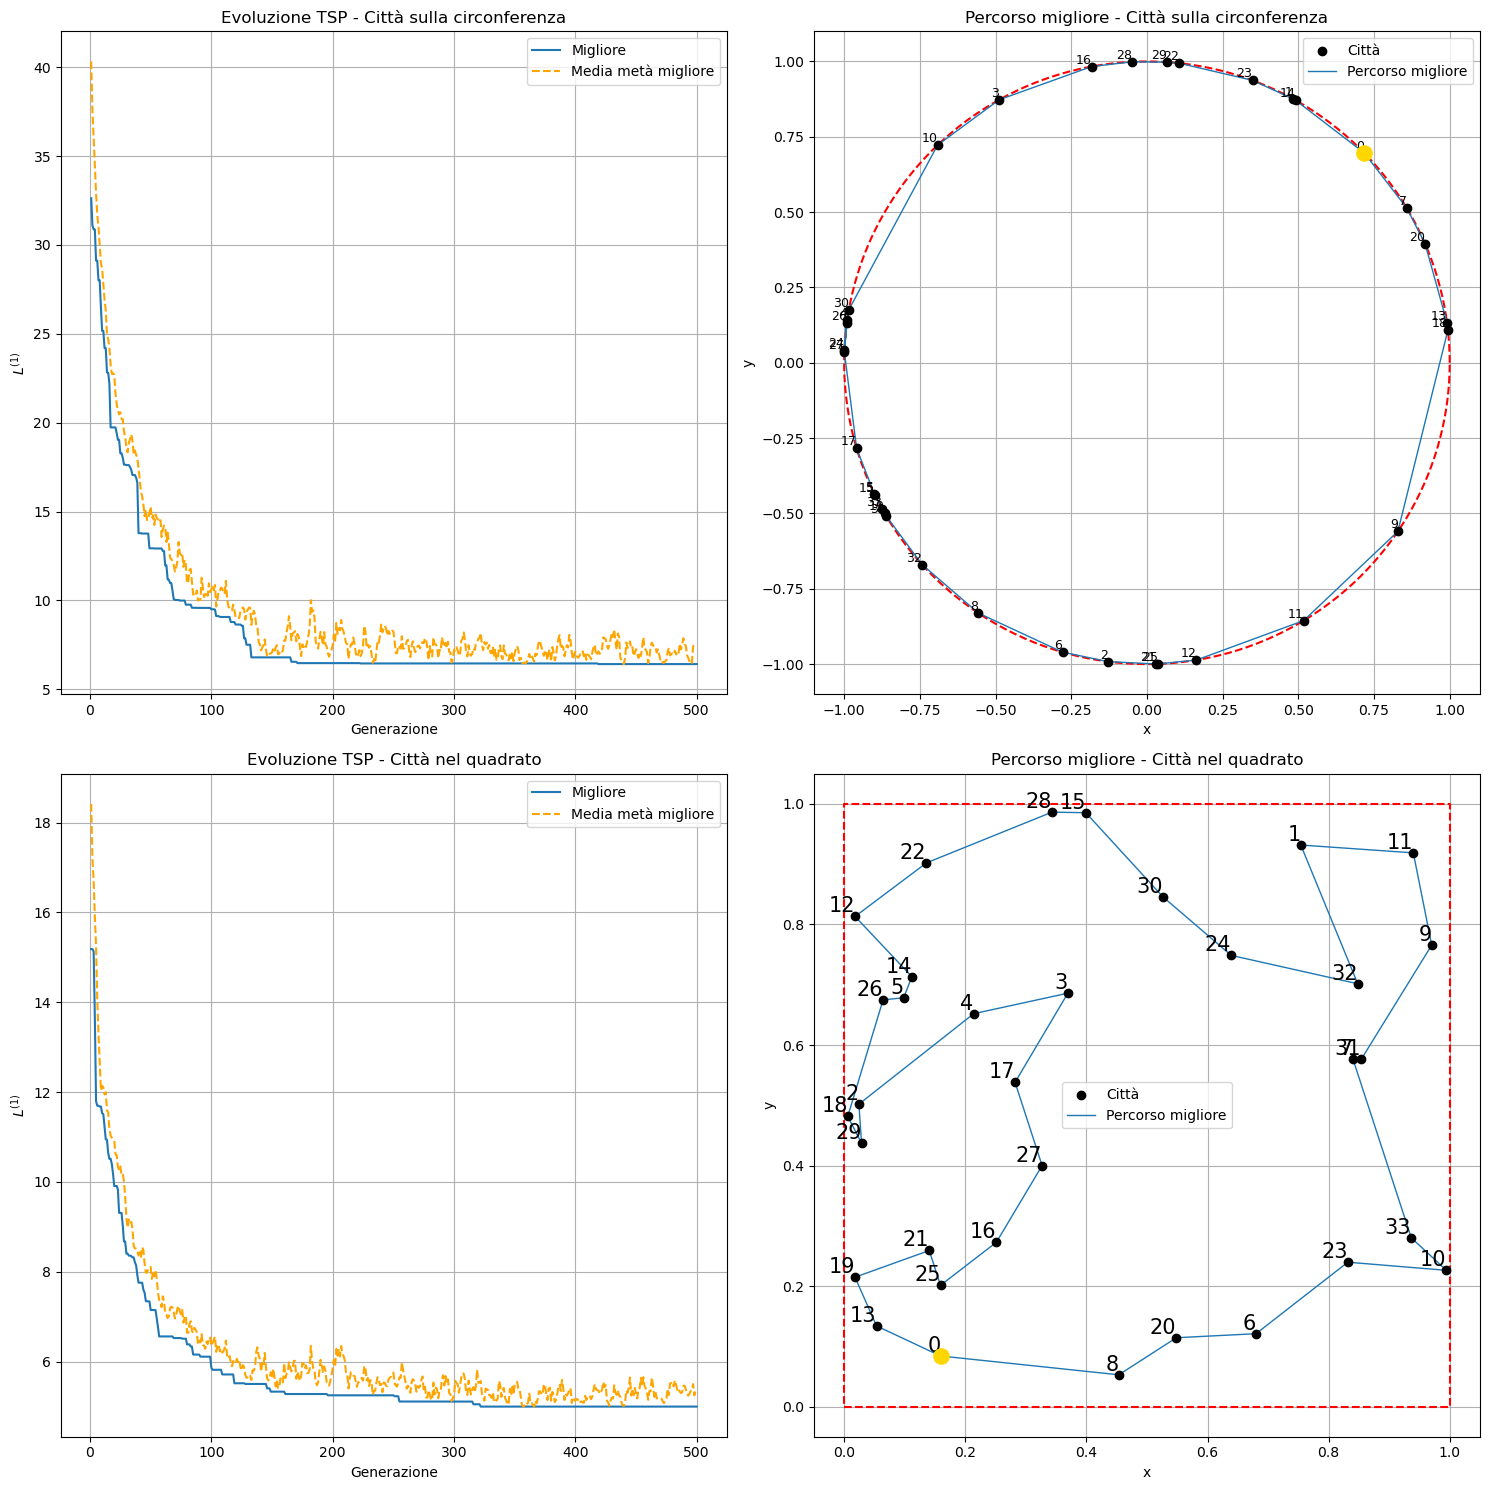

Best circonferenza:  6.42002
Best quadrato:  5.00033


In [1]:
import numpy as np
import matplotlib.pyplot as plt


#CASO 1: CITTÀ SULLA CIRCONFERENZA

#carico i dati di evoluzione: numero generazione, lunghezza L1 individuo migliore della generazione, media metà migliore
dati_cerchio=np.loadtxt("09.1/evoluzione_cerchio.dat")
gen_cerchio=dati_cerchio[:,0]
L1_best_cerchio=dati_cerchio[:,1]
L1_media_cerchio=dati_cerchio[:,2]

#carico le coordinate di tutte le città
coord_cerchio=np.loadtxt("09.1/coordinate_circonferenza.dat")
idx_circ=coord_cerchio[:,0]
x_circ=coord_cerchio[:,1]
y_circ=coord_cerchio[:,2]

#carico il percorso migliore
best_cerchio=np.loadtxt("09.1/best_circonferenza.dat")

#PRIMO GRAFICO: evoluzione di L1 in funzione della generazione
plt.figure(figsize=(15,15))

plt.subplot(2, 2, 1)
plt.plot(gen_cerchio, L1_best_cerchio,label="Migliore")
plt.plot(gen_cerchio, L1_media_cerchio, label="Media metà migliore", color="orange", linestyle="--")
plt.xlabel("Generazione")
plt.ylabel("$L^{(1)}$")
plt.title("Evoluzione TSP - Città sulla circonferenza")
plt.legend()
plt.grid(True)
plt.tight_layout()

#SECONDO GRAFICO: traiettoria percorso migliore
plt.subplot(2, 2, 2)

#plotto circonferenza
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta),linestyle="--",color="red")
#stampo tutte le città
plt.scatter(x_circ,y_circ,color="black",zorder=5,label="Città")

#stampo indici città
for i in range(len(idx_circ)):
    plt.text(x_circ[i], y_circ[i], str(int(idx_circ[i])),fontsize=9, ha='right', va='bottom')

#evidenzio città iniziale
i0=np.where(idx_circ==0)[0][0]

plt.scatter(x_circ[i0], y_circ[i0], color="gold", s=120, zorder=10)
    
#stampo il percorso (best_cerchio ha già la città iniziale ripetuta alla fine)
plt.plot(best_cerchio[:, 0], best_cerchio[:, 1], linewidth=1, label="Percorso migliore") #stampo percorso migliore
plt.xlabel("x")
plt.ylabel("y")
plt.title("Percorso migliore - Città sulla circonferenza")
plt.legend()
plt.grid(True)
plt.tight_layout()


#CASO 2: CITTÀ NEL QUADRATO
dati_quadrato=np.loadtxt("09.1/evoluzione_quadrato.dat")
gen_quadrato=dati_quadrato[:,0]
L1_best_quadrato=dati_quadrato[:,1]
L1_media_quadrato=dati_quadrato[:,2]

coord_quadrato=np.loadtxt("09.1/coordinate_quadrato.dat")
idx_quad=coord_quadrato[:,0]
x_quad=coord_quadrato[:,1]
y_quad=coord_quadrato[:,2]

best_quadrato=np.loadtxt("09.1/best_quadrato.dat")

#PRIMO GRAFICO: evoluzione di L1 in funzione della generazione
plt.subplot(2, 2, 3)

#stampo andamento L1
plt.plot(gen_quadrato, L1_best_quadrato,  label="Migliore")
plt.plot(gen_quadrato, L1_media_quadrato, label="Media metà migliore", color="orange", linestyle="--")
plt.xlabel("Generazione")
plt.ylabel("$L^{(1)}$")
plt.title("Evoluzione TSP - Città nel quadrato")
plt.legend()
plt.grid(True)
plt.tight_layout()

#SECONDO GRAFICO: traiettoria percorso migliore
#plotto quadrato
plt.subplot(2, 2, 4)

#coordinate dei vertici quadrato
square_x = [0, 1, 1, 0, 0]
square_y = [0, 0, 1, 1, 0]
plt.plot(square_x, square_y, linestyle="--", color="red") #stampo quadrato in cui ho estratto le posizioni delle città

plt.scatter(x_quad,y_quad,color="black", zorder=5, label="Città") #uso zorder per mettere in primo piano i punti delle città

#stampo indici città
for i in range(len(idx_quad)):
    plt.text(x_quad[i], y_quad[i], str(int(idx_quad[i])),fontsize=15, ha='right', va='bottom')

#evidenzio città iniziale
i0=np.where(idx_quad==0)[0][0]
plt.scatter(x_quad[i0], y_quad[i0], color="gold", s=120, zorder=10)
    
plt.plot(best_quadrato[:, 0], best_quadrato[:, 1], linewidth=1, label="Percorso migliore")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Percorso migliore - Città nel quadrato")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#stampo le lunghezze finali dei percorsi
best=np.loadtxt("09.1/best.dat")
print("Best circonferenza: ",best[0])
print("Best quadrato: ",best[1])

**COMMENTO AI RISULTATI**

I due grafici che riportano la traiettoria del percorso individuato come ottimale mostrano chiaramente il successo dell'algoritmo genetico: visivamente si ha la conferma che i percorsi trovati sono coerenti con i più brevi possibili. Nel caso di città disposte su una circonferenza, inoltre, notiamo che il percorso ottimale ha lunghezza pari a 6.42002, ovvero molto vicino alla lunghezza della circonferenza unitaria ($2\pi$): questa è una buona conferma della corretta implementazione e dell'efficacia dell'algoritmo genetico. Anche nel caso del quadrato, nonostante la distribuzione delle città sia molto più complessa rispetto alla circonferenza, il percorso trovato dall'algoritmo è verosimilmente quello ottimale. Infine, in entrambi i casi si verifica il rispetto dei vincoli richiesti: non vi sono infatti incroci, le città non sono ripetute e la città iniziale è il punto di partenza.

Si possono trarre delle considerazioni interessanti anche analizzando il primo grafico, che mette a confronto l'andamento dell'individuo migliore di ogni popolazione con l'andamento della media della metà migliore della popolazione, in funzione della generazione. Un dettaglio rilevante, che conferma il corretto funzionamento dell'algoritmo, è il fatto che la curva blu sia sempre minore della curva arancione: questo è un comportamento atteso, dal momento che la curva blu è associata all'individuo migliore di una particolare generazione, che quindi avrà una lunghezza sicuramente minore o uguale alla media delle lunghezze della metà migliore. D'altra parte, la curva arancione si trova sempre molto vicino alla curva blu: questo significa che la popolazione non contiene solamente un individuo "ottimale", ma è formata da un numero consistente di individui vantaggiosi, e questo avviene grazie all'azione combinata di selezione e crossover, che guidano la convergenza verso soluzioni migliori, e delle mutazioni, che garantiscono la variabilità genetica necessaria per evitare di rimanere intrappolati in minimi locali.

Inoltre, noto che l'andamento dell'individuo migliore procede "a gradini": questo è coerente con il funzionamento dell'algoritmo, in cui, a meno che non venga trovato un individuo con una lunghezza L1 inferiore, l'individuo migliore rimane il migliore della generazione precedente. Dal primo grafico noto che sono state sufficienti meno di 200 generazioni per trovare l'individuo migliore; dal secondo grafico invece noto che per il quadrato sono state necessarie poco più di 300 generazioni: infatti, questo è evidenziato dal fatto che il grafico blu, che indica la lunghezza L1 dell'individuo migliore, si stabilizza a un valore costante. Infine, il rapido andamento decrescente osservato nelle prime 100-150 generazioni riflette l'efficacia con cui l'algoritmo genetico sta esplorando lo spazio delle soluzioni alla ricerca dell'individuo migliore.